In [11]:
import numpy as np
import pandas as pd
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# load tsv with eval data
save_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(save_dir, 'real_parcellation_cerebellum.tsv')
D = pd.read_csv(saved_file, sep='\t')

In [13]:
# defube metrics to plot
metrics = ['random','variance','variance_mc','inverse_trace_mc','log_det_mc']
D = D[D['metric'].isin(metrics)]

In [14]:
custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

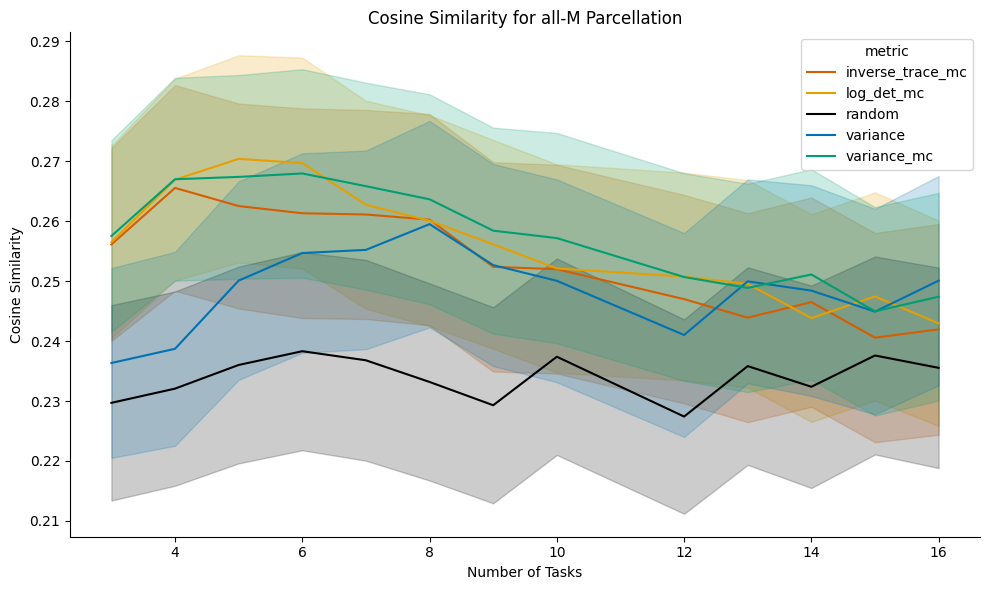

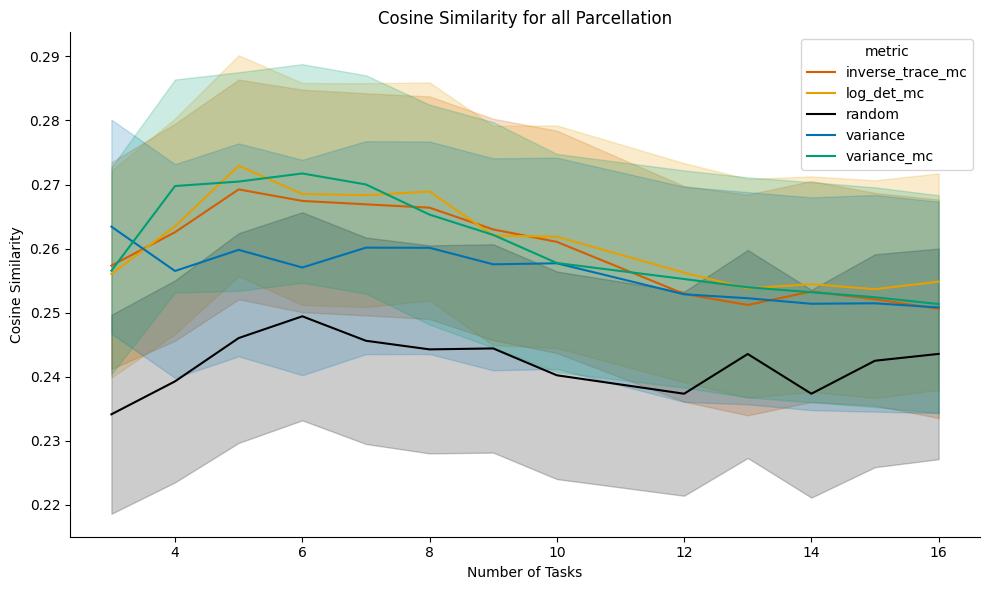

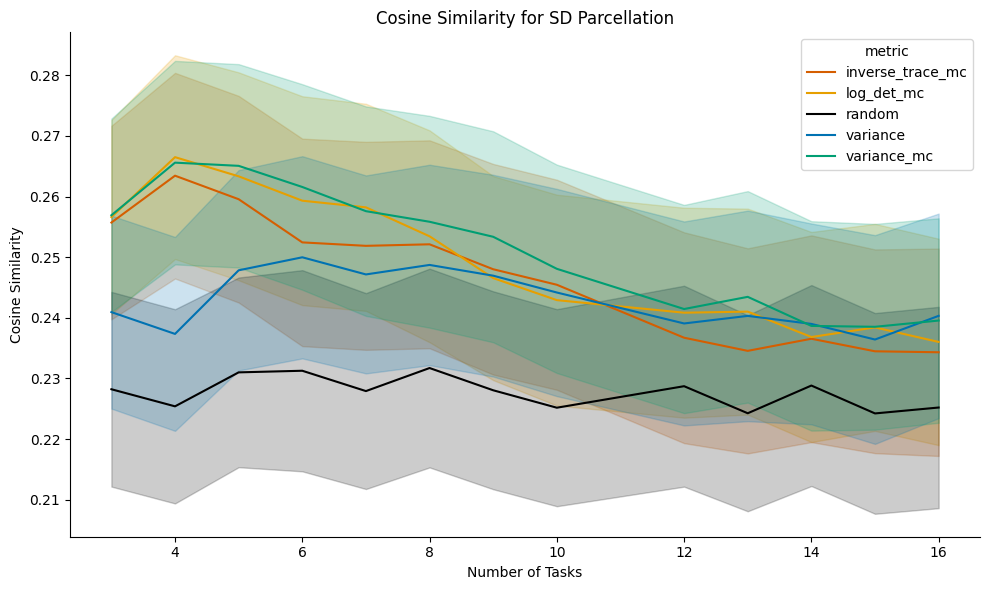

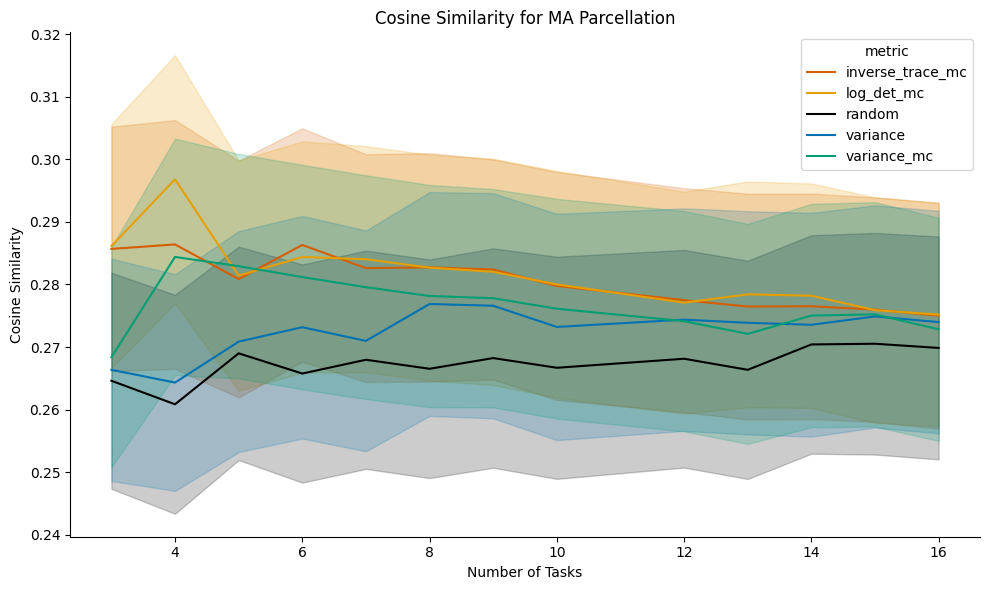

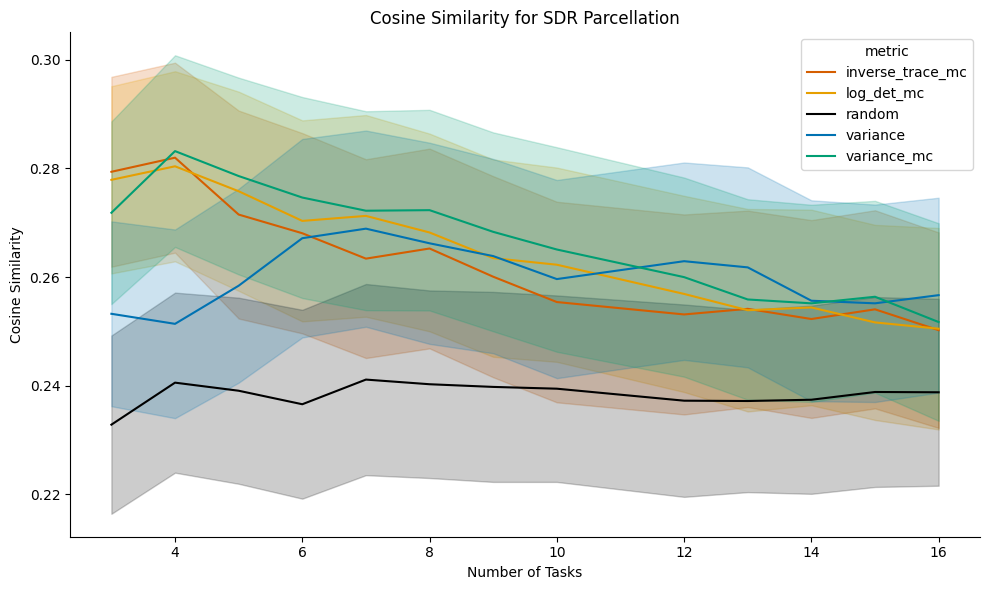

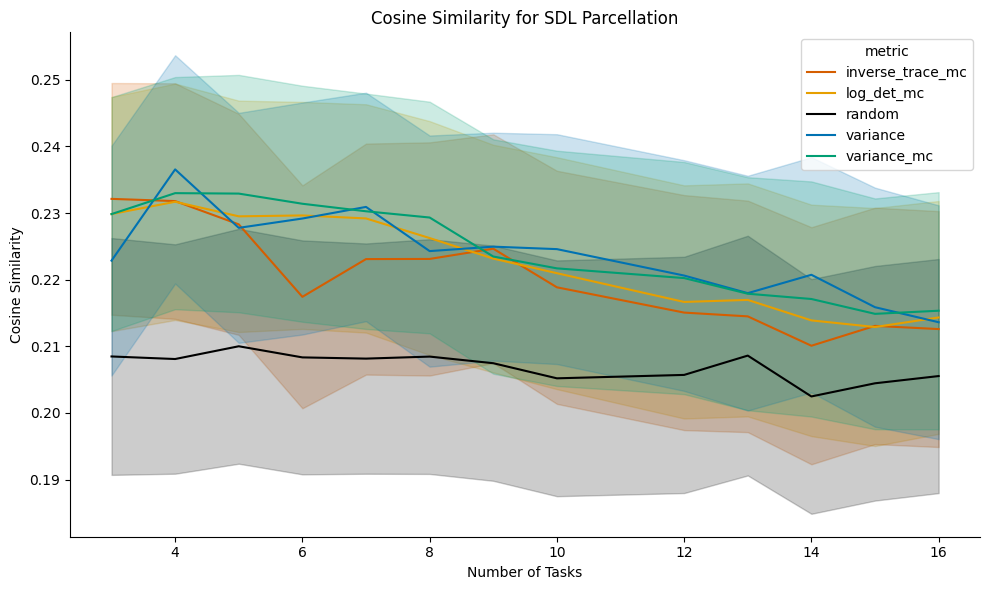

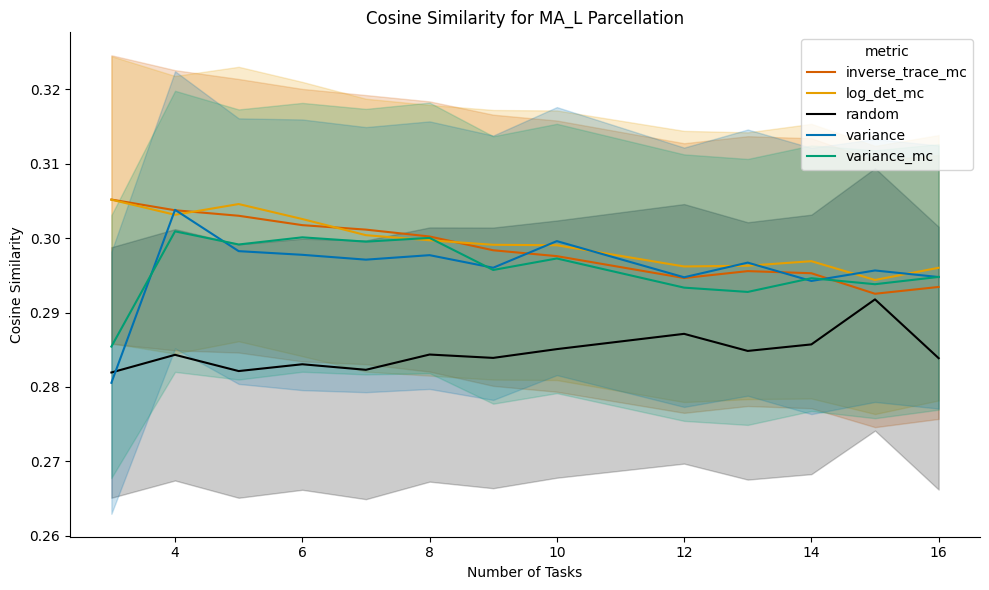

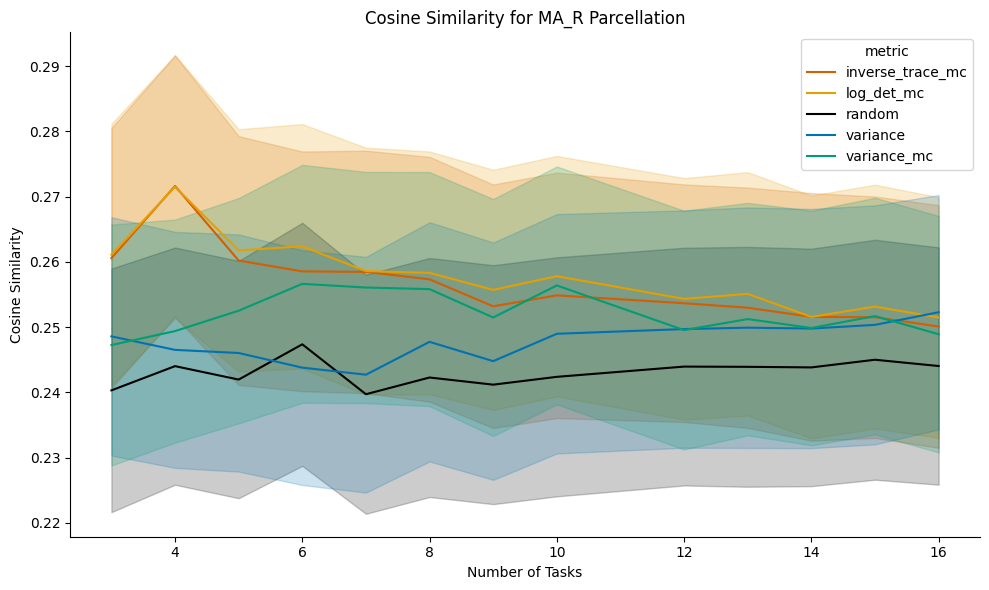

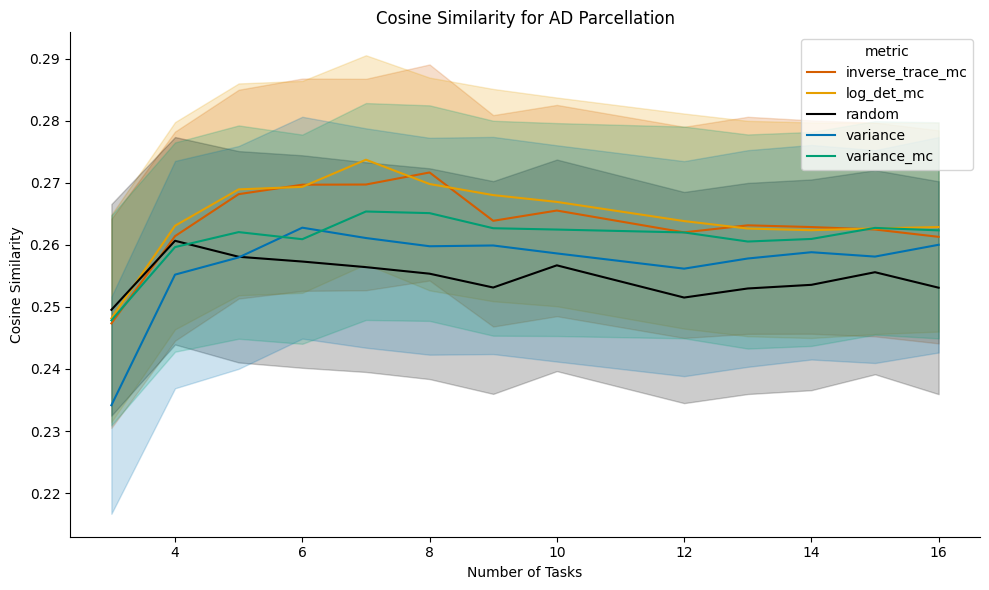

In [15]:
# check unique ROIs
rois = D['roi'].unique()
for roi in rois:
    df_roi = D[D['roi'] == roi]

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_roi,
        x="n_task",
        y="avg_cos_sim_per_subject",
        hue="metric",
        errorbar='se',
        palette=custom_palette,
    )

    plt.xlabel("Number of Tasks")
    plt.ylabel("Cosine Similarity")
    plt.title(f"Cosine Similarity for {roi} Parcellation")
    plt.tight_layout()
    sns.despine()
    # save_dir = 'C:/Users/barafat/Diedrichsenlab Dropbox/Lab Manager/Papers/MultiTaskBattery_paper/Figures'
    # plt.savefig(f"{save_dir}/real_parcellate_{roi}.pdf", format="pdf", bbox_inches="tight")
    plt.show()